# Segmentação de óleo, água e gás por meio de IA

##### data: Outubro de 2026

## Conteúdo:

1. Import de bibliotecas
2. Cortando imagem para se livrar de erros no dataset
3. Fazendo data augmentation e salvando em folder separado 
4. Criação de classe dataset e conversão para one hot encoding


#### 1. Imports: `Checar pyprojects.toml` para ver versões e bibliotecas usadas

In [42]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
import cv2
import random
import torch
from torch.utils.data import Dataset

#### 2. Cortando Imagem e salvando imagem cortada

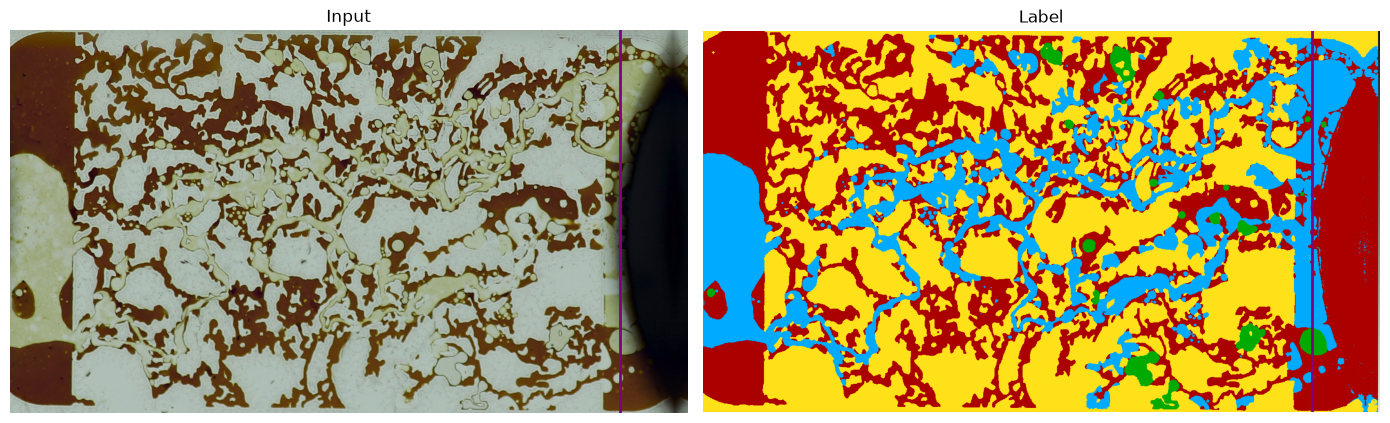

In [ ]:
# caminhos das imagens
input_img_path = r'C:\labmems\wag-segment\data\out_segmentation\original\input\outubro_2026_original.png'
label_img_path = r'C:\labmems\wag-segment\data\out_segmentation\original\label\outubro_2026_original.png'

input_img = Image.open(input_img_path)
label_img = Image.open(label_img_path)

# Posição horizontal relativa de onde o corte é feito:
# 0 --> esquerda
# 1 --> direita
# ajuste para valores entre 0 e 1
slice = 0.9

assert slice >= 0 and slice <= 1

x_input = slice * (input_img.width - 1)
x_label = slice * (label_img.width - 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))


ax[0].imshow(input_img)
ax[0].axvline(x=x_input, linewidth=2, color="purple")
ax[0].set_title(f"Input")
ax[0].axis("off")


ax[1].imshow(label_img)
ax[1].axvline(x=x_label, linewidth=2, color="purple")
ax[1].set_title(f"Label")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def slice_images(input_img, label_img, slice):
    """
    Corta as imagens a direita do parametro slice

    (tudo depois da reta roxa é descartado)

    BONUS: opcionalmente podemos extender essa função depois para corta à esquerda também
    se for necessário em outra imagem.

    Parametros
    ----------
    input_img : PIL.Image.Image
        Input image.
    label_img : PIL.Image.Image
        Label/mask image.
    slice : float
        posição horizontal relativa do corte no intervalo [0, 1].
        0 = left edge
        1 = right edge

    Returns
    -------
    input_crop : PIL.Image.Image
    label_crop : PIL.Image.Image
    """
    if not 0 <= slice <= 1:
        raise ValueError("slice must be between 0 and 1")

    # Convert relative position to pixel coordinates
    x_input = round(slice * input_img.width)
    x_label = round(slice * label_img.width)

    # PIL crop box: (left, top, right, bottom)
    input_crop = input_img.crop(
        (0, 0, x_input, input_img.height)
    )

    label_crop = label_img.crop(
        (0, 0, x_label, label_img.height)
    )

    return input_crop, label_crop



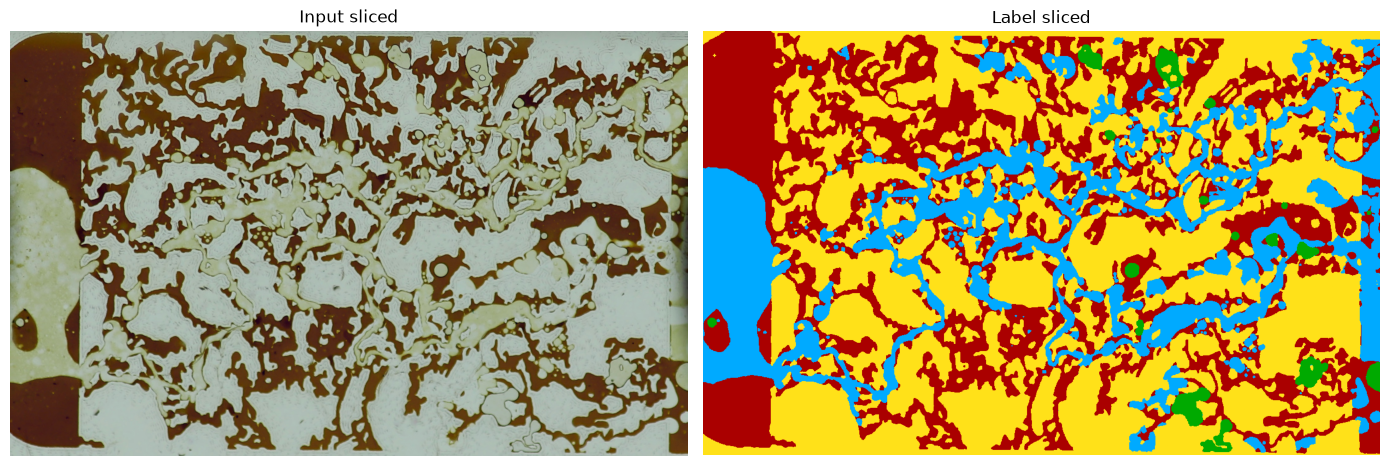

In [19]:
input_crop, label_crop = slice_images(
    input_img,
    label_img,
    slice=slice
)


# salvar imagens de folder
input_crop_save_path = r'C:\labmems\wag-segment\data\out_segmentation\sliced\input\out_2026.png'
label_crop_save_path = r'C:\labmems\wag-segment\data\out_segmentation\sliced\label\out_2026.png'

input_crop.save(input_crop_save_path)
label_crop.save(label_crop_save_path)


fig, ax = plt.subplots(1, 2, figsize=(14, 7))


ax[0].imshow(input_crop)
ax[0].set_title(f"Input sliced")
ax[0].axis("off")


ax[1].imshow(label_crop)
ax[1].set_title(f"Label sliced")
ax[1].axis("off")

plt.tight_layout()
plt.show()

#### 3. Fazendo Data Augmentation

Fazendo transformações lineares e elásticas na imagem para gerar novos dados

In [39]:
# HYPERPARAMETROS

NUM_IMAGENS = 50 # num de imagens aumentadas
HEIGHT = 770
WIDTH = 1400

In [40]:
def create_augmentation(height, width):
    """
    Cria pipeline de data augmentation.

    Tanto input quanto label recebem as mesmas transformações espaciais.
    Transformações de cor não são aplicadas para não mudar a natureza
    das imagens.

    Ajuste os valores nessa função para controlar a distorção, favor checar documentação do albumentations:
    https://github.com/albumentations-team/albumentations
    """

    return A.Compose(
        [
            A.HorizontalFlip(p=0.5),

            A.VerticalFlip(p=0.5),

            A.ShiftScaleRotate(
                shift_limit=0.5,
                scale_limit=(0, 1.5),
                rotate_limit=180,
                border_mode=cv2.BORDER_REFLECT,
                p=1.0
            ),

            A.GridDistortion(
                num_steps=4,
                distort_limit=0.2,
                p=0.7
            ),

            A.RandomResizedCrop(
                size=(height, width),
                scale=(0.8, 1.0),
                ratio=(0.75, 1.33),
                interpolation=cv2.INTER_LINEAR,
                p=1.0
            ),

            A.Resize(
                height=height,
                width=width,
                interpolation=cv2.INTER_LINEAR,
                p=1.0
            ),
        ],

        additional_targets={
            "image2": "image"
        }
    )


def augment_images(img1, img2, height, width, seed=None):
    """
    Aplica exatamente as mesmas transformações em duas imagens RGB.

    Parameters
    ----------
    img1, img2 : PIL.Image.Image
        Imagens RGB.

    height, width : int
        Dimensões finais.

    seed : int, optional
        Seed para reprodutibilidade.

    Returns
    -------
    PIL.Image.Image, PIL.Image.Image
        As duas imagens aumentadas.
    """

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Garante RGB
    img1 = img1.convert("RGB")
    img2 = img2.convert("RGB")

    # PIL -> NumPy
    img1_np = np.array(img1)
    img2_np = np.array(img2)

    # Aplica a mesma transformação nas duas
    augmented = create_augmentation(height, width)(
        image=img1_np,
        image2=img2_np
    )

    # NumPy -> PIL
    aug_img1 = Image.fromarray(augmented["image"])
    aug_img2 = Image.fromarray(augmented["image2"])

    return aug_img1, aug_img2


def generate_augmented_images(
    input_img,
    label_img,
    input_save_dir,
    label_save_dir,
    height,
    width,
    num_images,
    seed=None
):
    """
    Gera e salva múltiplos pares de imagens aumentadas.

    Cada par recebe exatamente as mesmas transformações espaciais.

    Parameters
    ----------
    input_img : PIL.Image.Image
        Imagem de entrada.

    label_img : PIL.Image.Image
        Imagem label correspondente.

    input_save_dir : str or Path
        Pasta onde serão salvas as imagens de input.

    label_save_dir : str or Path
        Pasta onde serão salvas as labels.

    height, width : int
        Dimensões finais das imagens.

    num_images : int
        Número de pares aumentados a serem gerados.

    seed : int, optional
        Seed base para reprodutibilidade.
    """

    # ---------------------------------------------------------
    # Resize input e label para as mesmas dimensões
    # PIL usa (width, height)
    # ---------------------------------------------------------
    input_img = input_img.resize(
        (width, height),
        resample=Image.Resampling.NEAREST
    )

    label_img = label_img.resize(
        (width, height),
        resample=Image.Resampling.NEAREST
    )

    # ---------------------------------------------------------
    # Gera as imagens aumentadas
    # ---------------------------------------------------------
    for i in range(num_images):

        # Seed diferente para cada augmentation,
        # mas reprodutível entre execuções
        current_seed = None if seed is None else seed + i

        # Aplica augmentation
        aug_input, aug_label = augment_images(
            input_img,
            label_img,
            height=height,
            width=width,
            seed=current_seed
        )

        # Mesmo nome para input e label
        filename = f"aug_{i:04d}.png"

        input_save_path = os.path.join(input_save_dir, filename)
        label_save_path = os.path.join(label_save_dir, filename)

        # Salva as imagens
        aug_input.save(input_save_path)
        aug_label.save(label_save_path)

    print(f"{num_images} pares de imagens gerados.")

In [47]:
input_save_dir = r"C:\labmems\wag-segment\data\out_segmentation\augmented\input"
label_save_dir = r"C:\labmems\wag-segment\data\out_segmentation\augmented\label"

generate_augmented_images(
    input_img=input_crop,
    label_img=label_crop,
    input_save_dir=input_save_dir,
    label_save_dir=label_save_dir,
    height=HEIGHT,
    width=WIDTH,
    num_images=NUM_IMAGENS,
    seed=42
)

c:\labmems\wag-segment\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


50 pares de imagens gerados.


#### 4. Codificando classes na máscara de acordo com a cor e contruindo classe de dataset

Classes e escala RGB:

- Água: Azul (0, 170, 255)
- Óleo: Vermelho (170, 0, 0)
- Gás: Verde (0, 170, 0)
- MiMo: Amarelo (255, 255, 25)

Vamos mapear para números inteiros:

- MiMo: Classe 0
- Água: Classe 1
- Óleo: Classe 2
- Gás: Classe 3


In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

        # RGB color -> class index
        self.color_to_class = {
            (255, 255, 25): 0,  # Mimo: amarelo
            (0, 170, 255): 1,  # Água: azul
            (170, 0, 0): 2,  # Óleo: vermelho
            (0, 170, 0): 3,  # Gás: verde
        }

    def _mask_to_classes(self, mask):
        """
        Convert an RGB segmentation mask to class indices by assigning
        each pixel to the nearest class color in RGB Euclidean distance.

        Parameters
        ----------
        mask : np.ndarray
            Shape [H, W, 3], typically dtype uint8.

        Returns
        -------
        np.ndarray
            Shape [H, W], dtype int64, containing class IDs.
        """

        # [C, 3]
        colors = np.array(
            list(self.color_to_class.keys()),
            dtype=np.float32
        )

        # [C]
        class_ids = np.array(
            list(self.color_to_class.values()),
            dtype=np.int64
        )

        # [H, W, 3] -> [H, W, 1, 3]
        pixels = mask.astype(np.float32)[..., None, :]

        # Broadcasting:
        #
        # pixels: [H, W, 1, 3]
        # colors:          [C, 3]
        #
        # result: [H, W, C]
        distances_sq = np.sum(
            (pixels - colors) ** 2,
            axis=-1
        )

        # For every pixel, find nearest color.
        # [H, W, C] -> [H, W]
        nearest = np.argmin(distances_sq, axis=-1)

        # Convert color index -> actual class ID
        target = class_ids[nearest]

        return target

    def __getitem__(self, idx):
        # -----------------------
        # Load
        # -----------------------
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("RGB")

        image = np.asarray(image)
        mask = np.asarray(mask)

        # -----------------------
        # RGB -> class IDs
        # -----------------------
        mask = self._mask_to_classes(mask)

        # -----------------------
        # To tensors
        # -----------------------
        image = torch.from_numpy(image.copy())
        image = image.permute(2, 0, 1).float() / 255.0

        mask = torch.from_numpy(mask).long()

        return image, mask

    def __len__(self):
        return len(self.image_paths)

In [61]:
img_paths = os.listdir(input_save_dir)
label_paths = os.listdir(label_save_dir)

for name_idx in range(len(img_paths)):
    img_paths[name_idx] = os.path.join(input_save_dir, img_paths[name_idx])
    label_paths[name_idx] = os.path.join(label_save_dir, label_paths[name_idx])


dataset = SegmentationDataset(img_paths, label_paths)

len(dataset)

50

In [62]:
dataset[0]

(tensor([[[0.2863, 0.2784, 0.2706,  ..., 0.2706, 0.2824, 0.3059],
          [0.3098, 0.3020, 0.2863,  ..., 0.2902, 0.2824, 0.3176],
          [0.3137, 0.3098, 0.3059,  ..., 0.3333, 0.2941, 0.2980],
          ...,
          [0.7098, 0.6902, 0.6706,  ..., 0.3020, 0.3059, 0.3098],
          [0.7098, 0.6980, 0.6824,  ..., 0.2980, 0.3020, 0.3059],
          [0.7098, 0.7059, 0.6941,  ..., 0.3020, 0.3020, 0.3020]],
 
         [[0.1529, 0.1451, 0.1451,  ..., 0.1647, 0.1569, 0.1647],
          [0.1725, 0.1647, 0.1569,  ..., 0.1843, 0.1529, 0.1686],
          [0.1765, 0.1725, 0.1686,  ..., 0.2314, 0.1608, 0.1412],
          ...,
          [0.7333, 0.7216, 0.7098,  ..., 0.2902, 0.3020, 0.3098],
          [0.7294, 0.7255, 0.7176,  ..., 0.2941, 0.3020, 0.3098],
          [0.7216, 0.7255, 0.7216,  ..., 0.3020, 0.3098, 0.3137]],
 
         [[0.0588, 0.0627, 0.0627,  ..., 0.0667, 0.0471, 0.0510],
          [0.0627, 0.0627, 0.0667,  ..., 0.1020, 0.0588, 0.0627],
          [0.0549, 0.0588, 0.0588,  ...,